<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#bagging perfrom the galss data set


In [1]:
import kagglehub
path = kagglehub.dataset_download("prashant111/glass-identification-dataset")

100%|██████████| 8.82k/8.82k [00:00<00:00, 13.8MB/s]

Extracting files...


In [2]:
import pandas as pd
import os

# List the contents of the directory to find the data file
print(os.listdir(path))

# Correcting the filename to 'glass_data.csv' based on the directory listing
df = pd.read_csv(os.path.join(path, 'glass_data.csv'))

# Display the first few rows of the DataFrame
df.head()

['datapackage.json', 'glass_data.csv']


,column_a,column_b,column_c,column_d,column_e,column_f,column_g,column_h,column_i,column_j,column_k
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


Decision Tree Classifier Accuracy: 0.6462


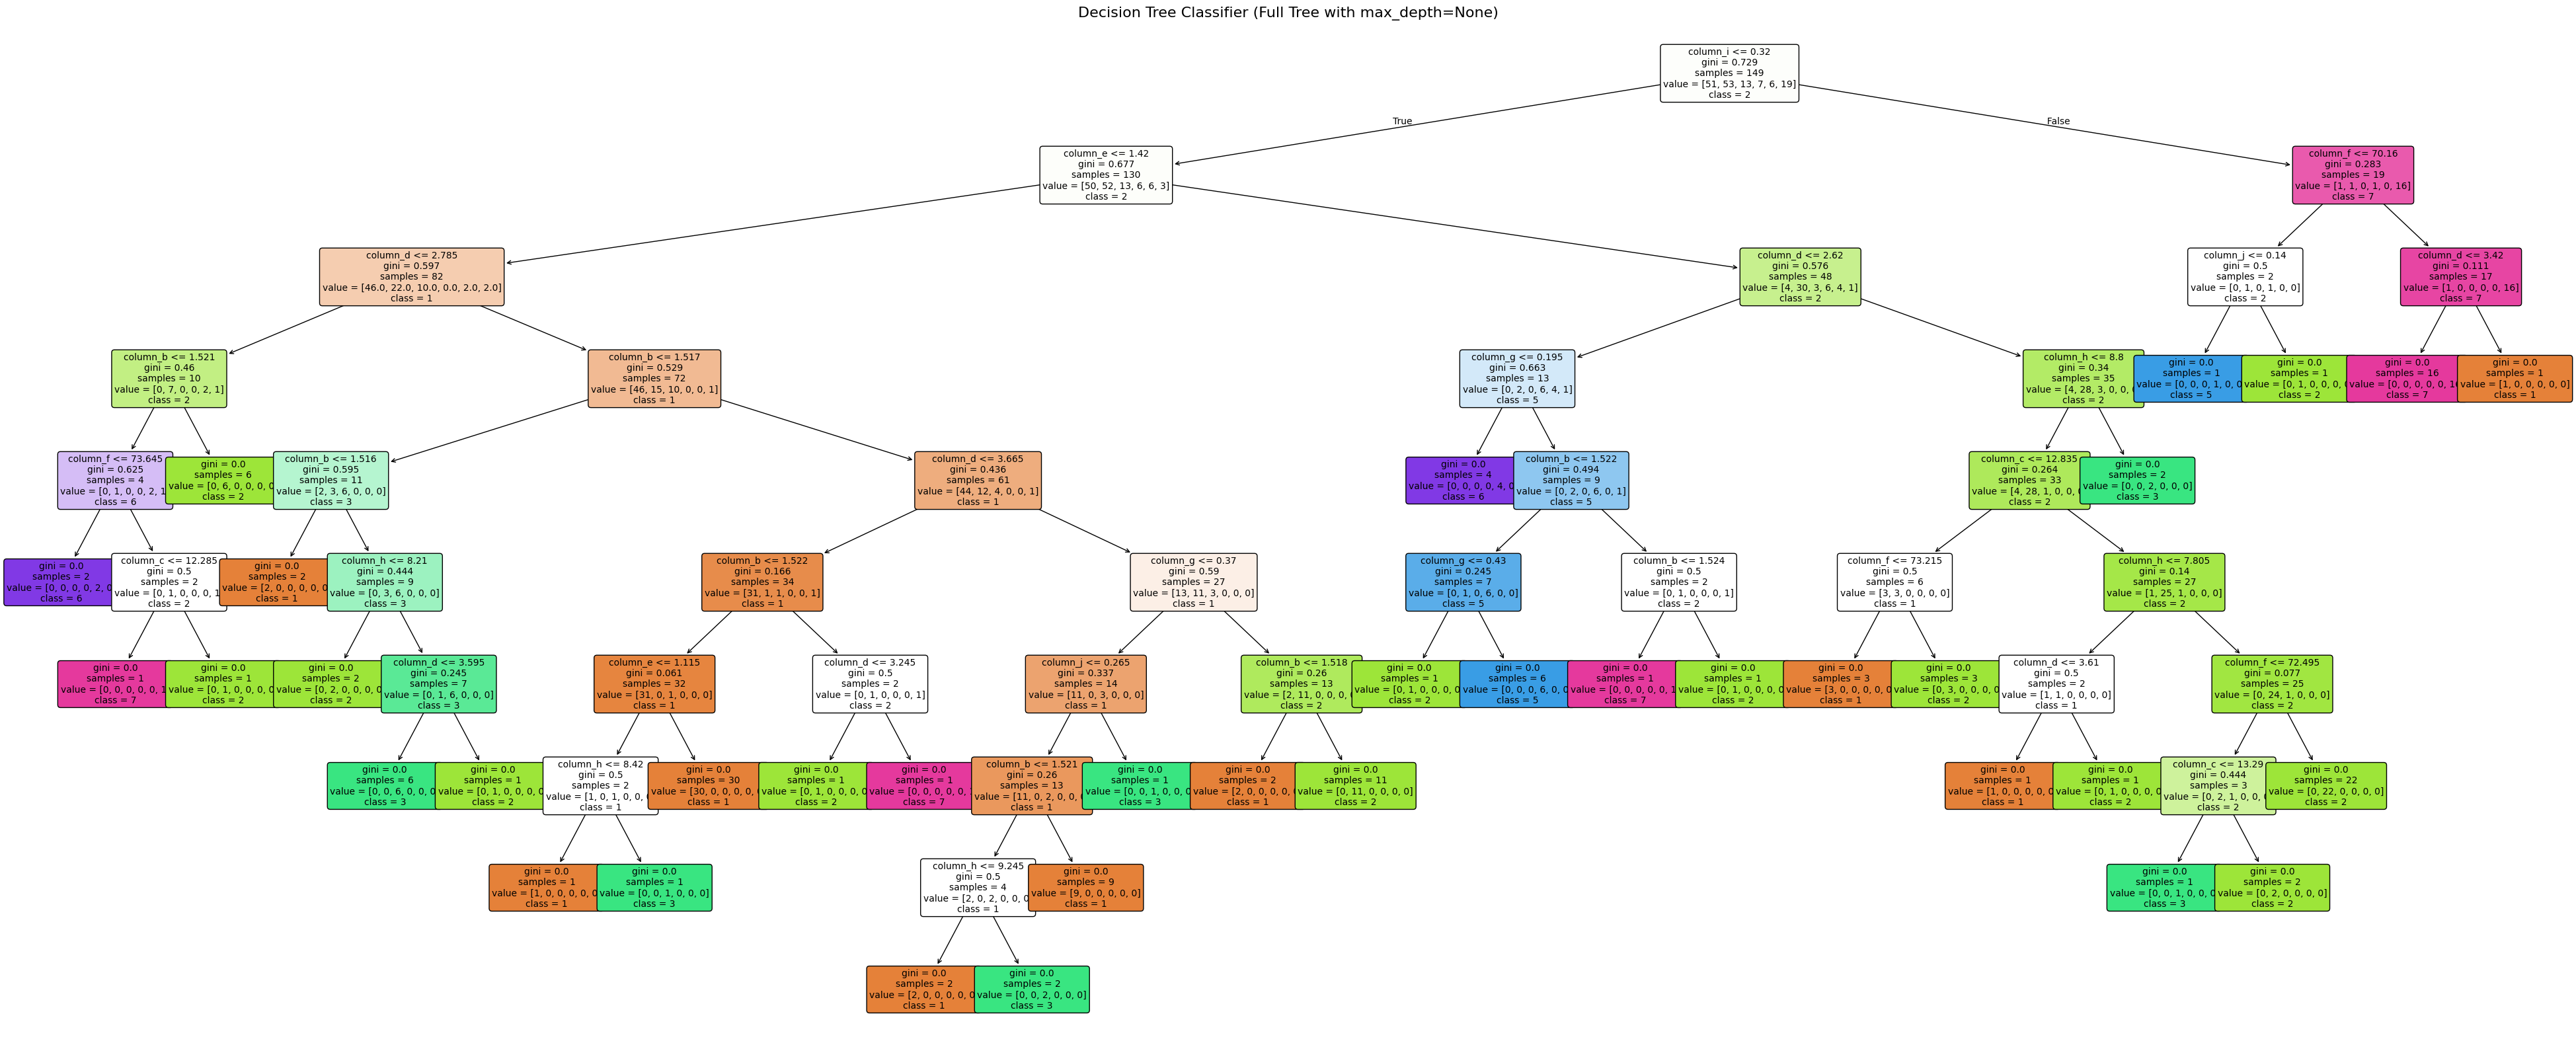

Note: The visualization might be very large and require zooming due to max_depth=None.


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X = df[['column_b', 'column_c', 'column_d', 'column_e', 'column_f', 'column_g', 'column_h', 'column_i', 'column_j']]
y = df['column_k']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier with max_depth=None
dt_classifier = DecisionTreeClassifier(max_depth=None, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy:.4f}")

# --- Geometric Visualization of the Decision Tree ---
# Prepare class names from the unique values in the target variable
class_names = [str(int(c)) for c in sorted(y.unique())]

plt.figure(figsize=(50, 20)) # Adjust figure size for better visibility of a potentially deep tree
plot_tree(dt_classifier,
          feature_names=X.columns.tolist(),
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Classifier (Full Tree with max_depth=None)", fontsize=16)
plt.show()

print("Note: The visualization might be very large and require zooming due to max_depth=None.")

In [4]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# The X_train, X_test, y_train, y_test are already defined from the previous cell.

# Initialize the base estimator (Decision Tree Classifier with max_depth=None)
base_estimator = DecisionTreeClassifier(max_depth=None, random_state=42)

# Initialize the Bagging Classifier
# n_estimators: The number of base estimators in the ensemble.
# max_samples: The number of samples to draw from X to train each base estimator.
# max_features: The number of features to draw from X to train each base estimator.
# oob_score: Whether to use out-of-bag samples to estimate the generalization accuracy.
# random_state for reproducibility.
bagging_classifier = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=100, # Common number of estimators
    max_samples=1.0, # Use all samples for each base estimator
    max_features=1.0, # Use all features for each base estimator
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bagging = bagging_classifier.predict(X_test)

# Evaluate the model
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")

Bagging Classifier Accuracy: 0.7846


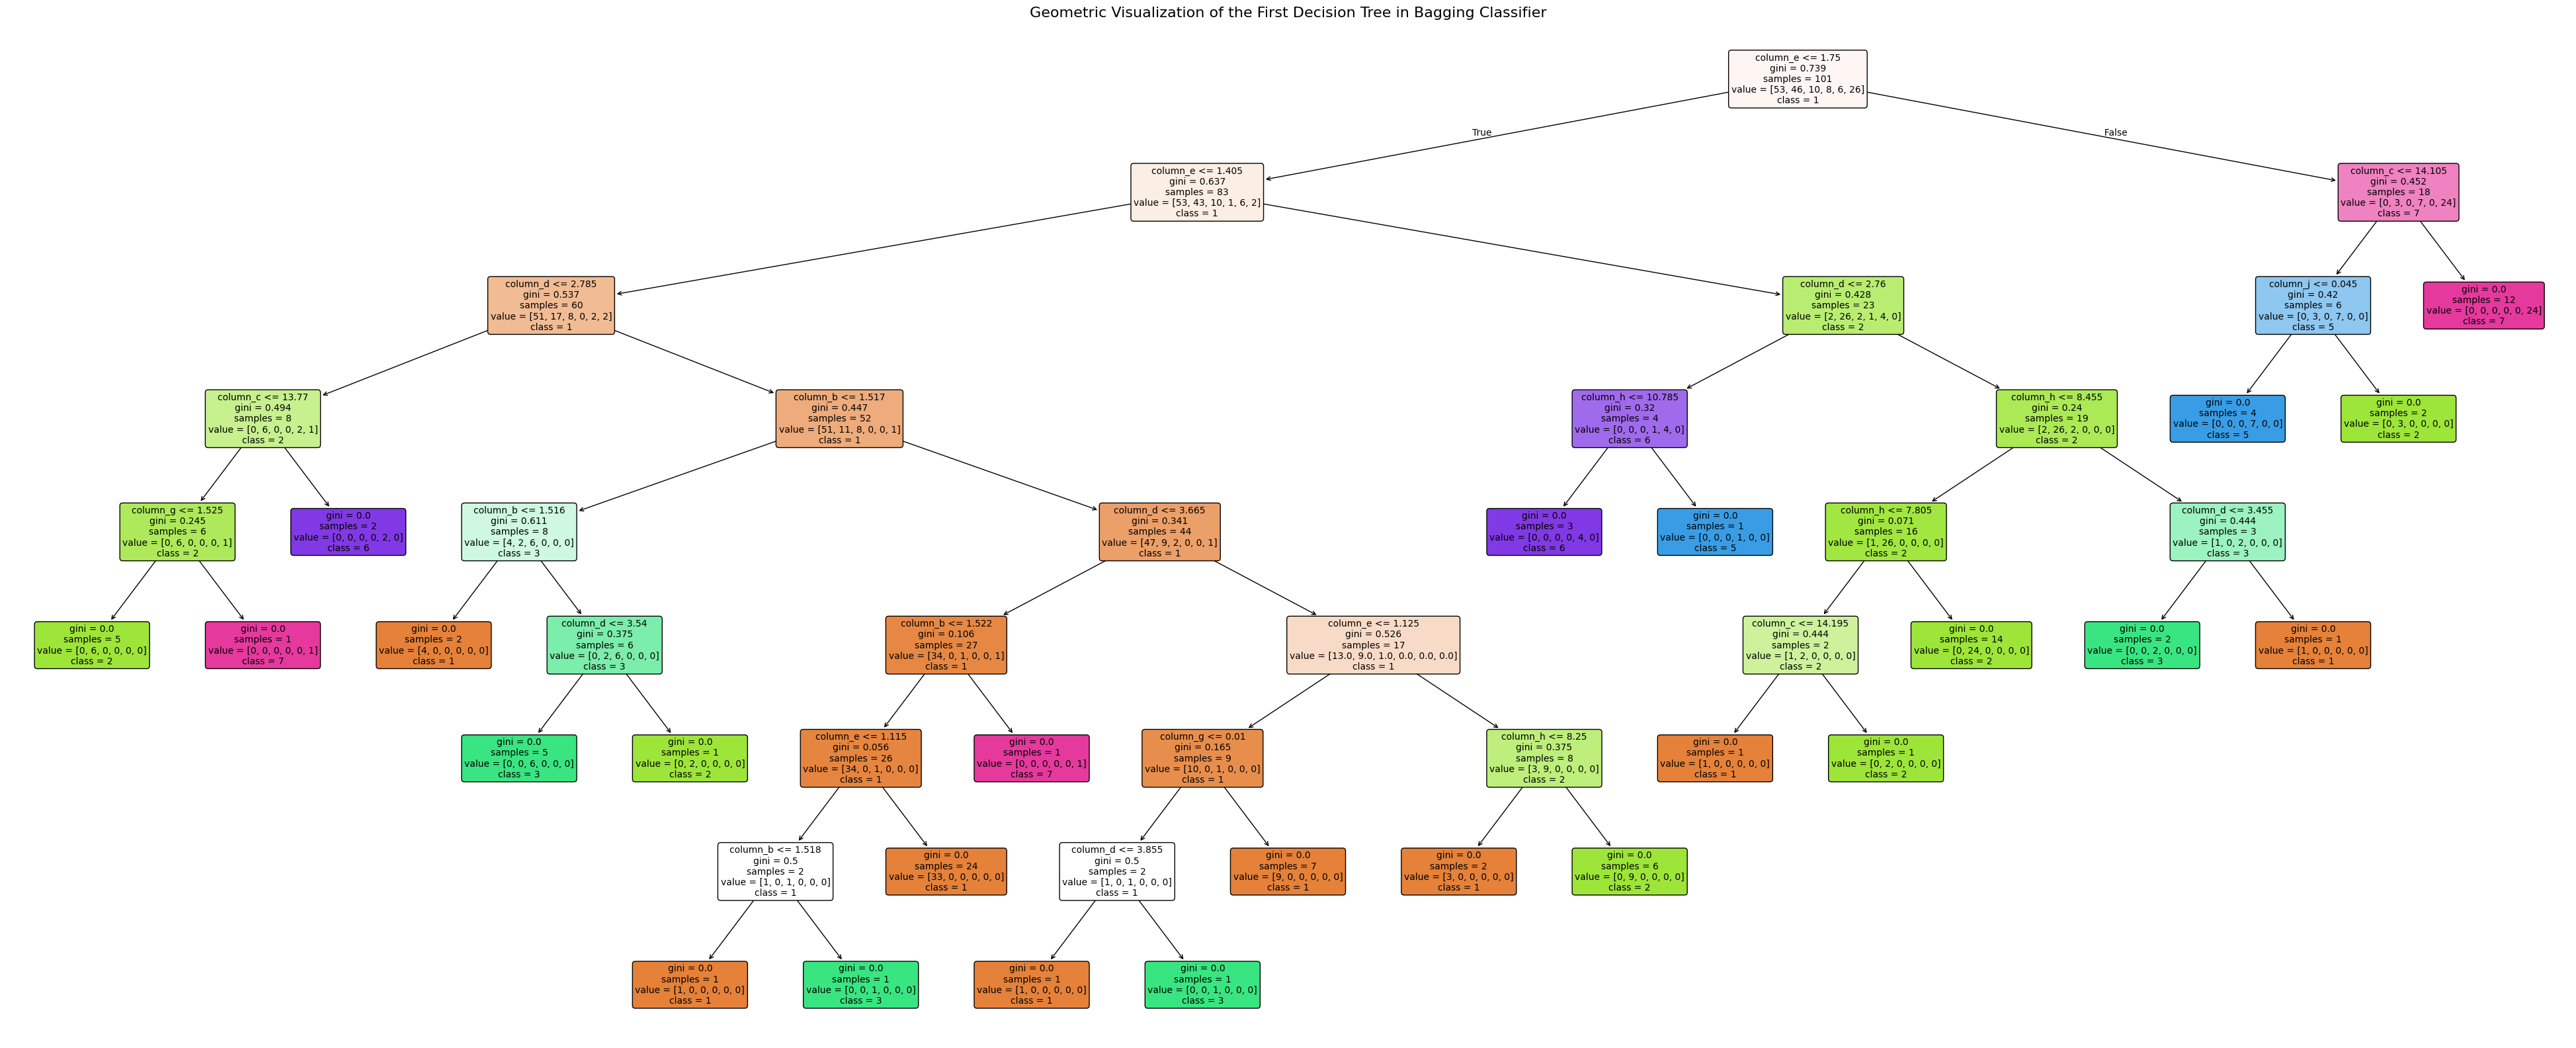

This visualization shows the first individual decision tree from the Bagging Classifier ensemble.


In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the first estimator (decision tree) from the Bagging Classifier
# Note: BaggingClassifier is an ensemble, so we visualize one of its base estimators.
first_tree = bagging_classifier.estimators_[0]

# Prepare class names from the unique values in the target variable
# 'y' is already defined from previous cells
class_names = [str(int(c)) for c in sorted(y.unique())]

plt.figure(figsize=(50, 20)) # Adjust figure size for better visibility
plot_tree(first_tree,
          feature_names=X.columns.tolist(), # X is defined in previous cells
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Geometric Visualization of the First Decision Tree in Bagging Classifier", fontsize=16)
plt.show()

print("This visualization shows the first individual decision tree from the Bagging Classifier ensemble.")

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
X = df[['column_b', 'column_c', 'column_d', 'column_e', 'column_f', 'column_g', 'column_h', 'column_i', 'column_j']]
y = df['column_k']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Define the parameter grid for Decision Tree
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier,
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='accuracy',
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Perform Grid Search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# Get the best estimator (model) from GridSearchCV
best_dt_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_dt = best_dt_model.predict(X_test)

# Evaluate the best model on the test set
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
print(f"Test Set Accuracy with Tuned Decision Tree: {accuracy_tuned_dt:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.6439
Test Set Accuracy with Tuned Decision Tree: 0.6923


In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter grid for BaggingClassifier, including its base estimator's parameters
param_grid_bagging = {
    'n_estimators': [10, 50, 100], # Number of base estimators (trees)
    'max_samples': [0.7, 1.0],     # Fraction of samples to draw for each base estimator
    'max_features': [0.7, 1.0],    # Fraction of features to draw for each base estimator
    'estimator__max_depth': [None, 5, 10, 15, 20], # Hyperparameters for the base Decision Tree
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Initialize the base estimator (Decision Tree Classifier)
# It's important to pass a non-fitted estimator to BaggingClassifier's `estimator` parameter
base_dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging Classifier with the base estimator
bagging_classifier = BaggingClassifier(estimator=base_dt_classifier, random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search_bagging = GridSearchCV(estimator=bagging_classifier,
                                   param_grid=param_grid_bagging,
                                   cv=5, # 5-fold cross-validation
                                   scoring='accuracy',
                                   n_jobs=-1, # Use all available cores
                                   verbose=2)

# Perform Grid Search on the training data
grid_search_bagging.fit(X_train, y_train)

# Get the best parameters and best score
best_params_bagging = grid_search_bagging.best_params_
best_score_bagging = grid_search_bagging.best_score_

print(f"Best Hyperparameters for Bagging Classifier: {best_params_bagging}")
print(f"Best Cross-Validation Accuracy for Bagging Classifier: {best_score_bagging:.4f}")

# Get the best estimator (model) from GridSearchCV
best_bagging_model = grid_search_bagging.best_estimator_

# Make predictions on the test set using the best Bagging model
y_pred_tuned_bagging = best_bagging_model.predict(X_test)

# Evaluate the best model on the test set
accuracy_tuned_bagging = accuracy_score(y_test, y_pred_tuned_bagging)
print(f"Test Set Accuracy with Tuned Bagging Classifier: {accuracy_tuned_bagging:.4f}")

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Hyperparameters for Bagging Classifier: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 50}
Best Cross-Validation Accuracy for Bagging Classifier: 0.7513
Test Set Accuracy with Tuned Bagging Classifier: 0.7538


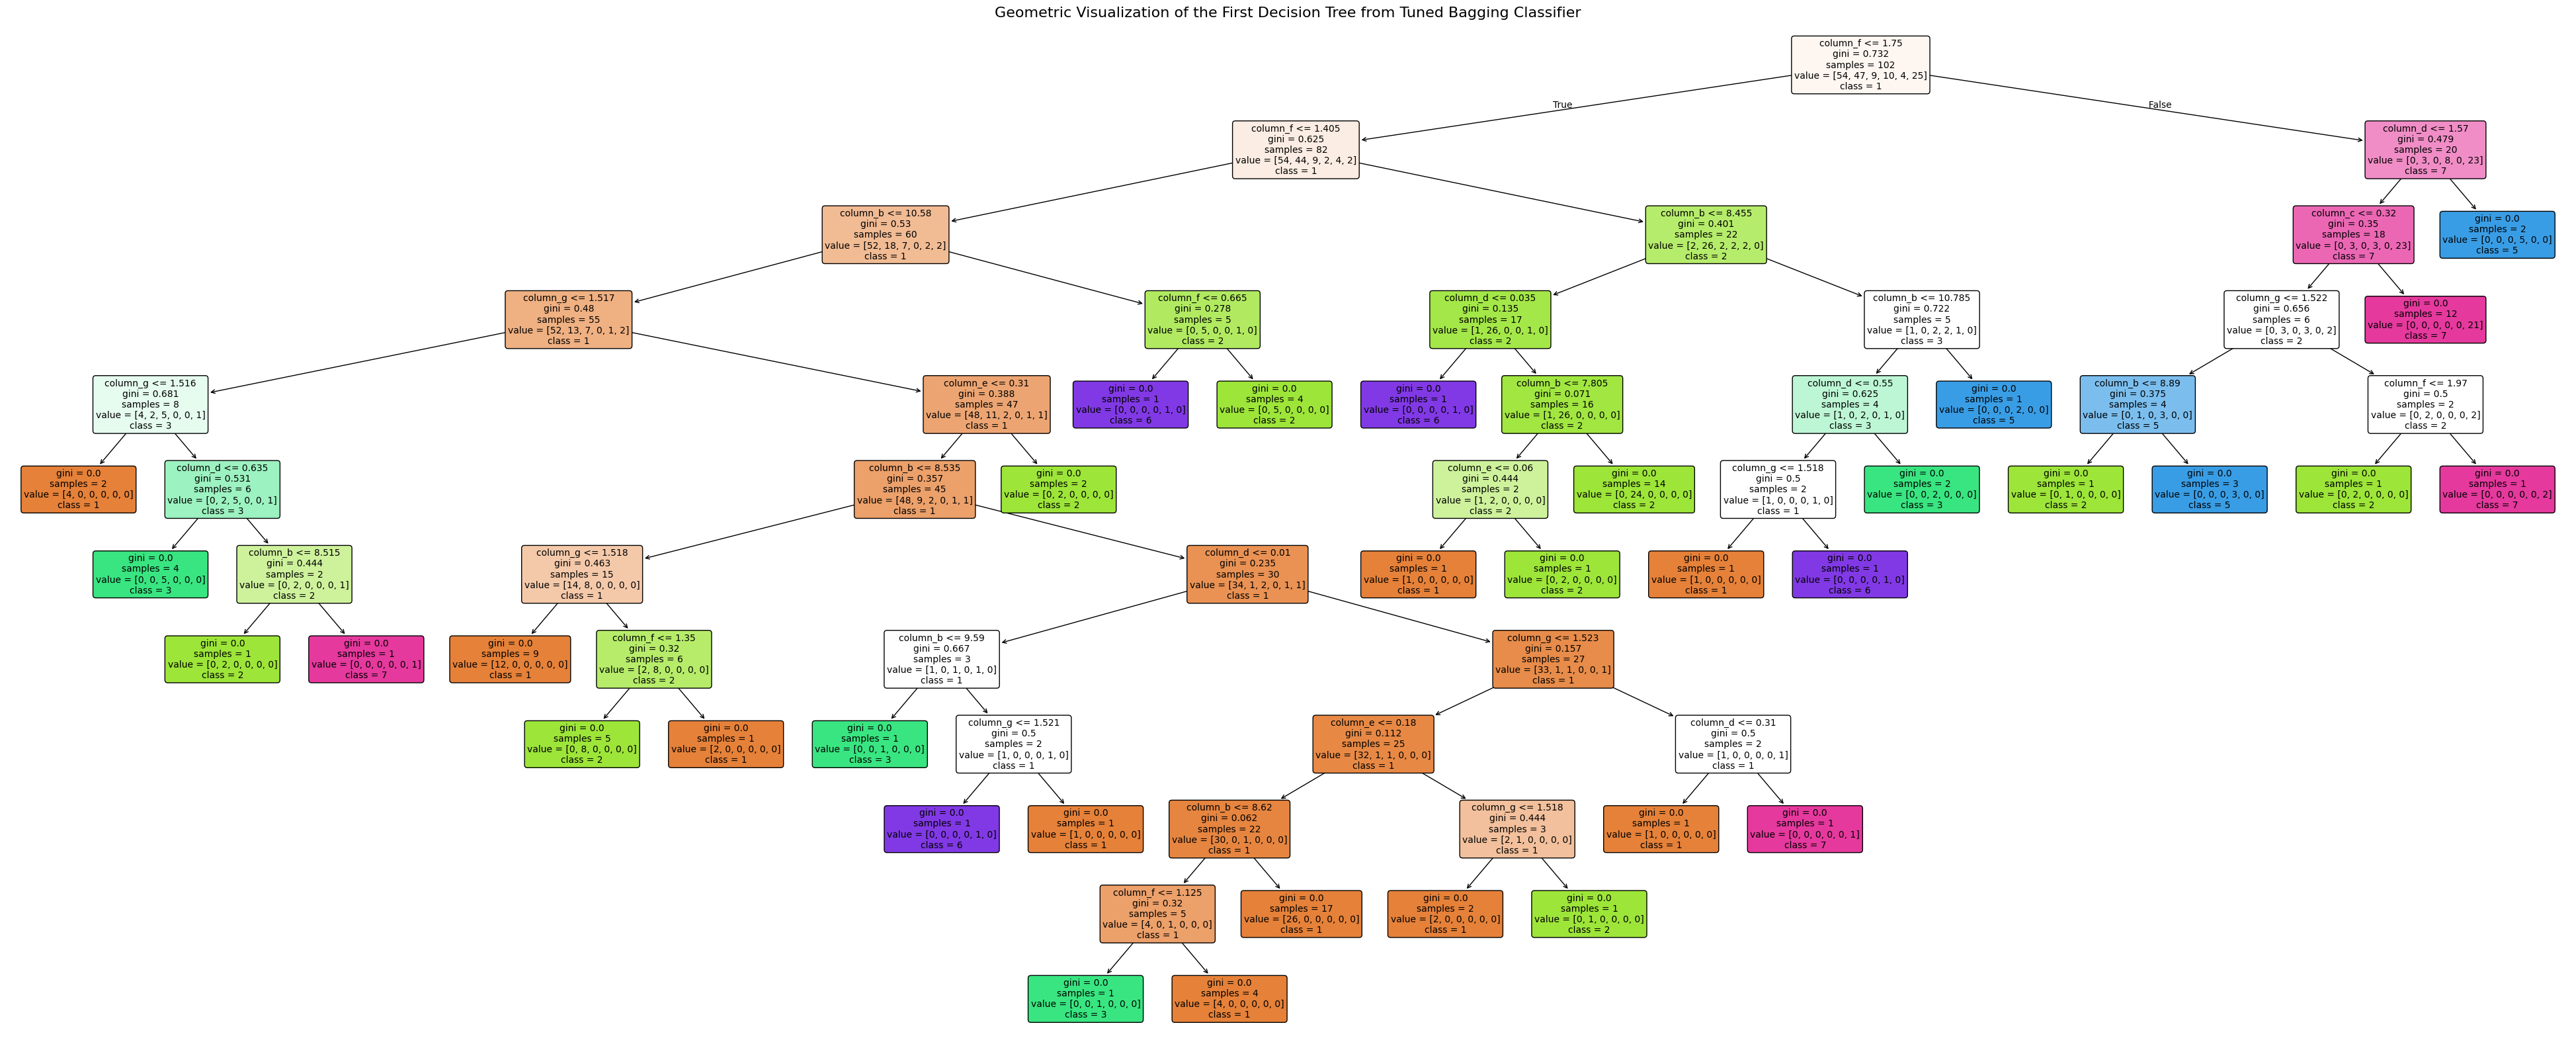

This visualization shows the first individual decision tree from the best-tuned Bagging Classifier ensemble.


In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the best estimator (model) from GridSearchCV for Bagging Classifier
# best_bagging_model was obtained from the previous cell's execution

# Check if best_bagging_model is a fitted BaggingClassifier and has estimators
if 'best_bagging_model' in locals() and hasattr(best_bagging_model, 'estimators_') and len(best_bagging_model.estimators_) > 0:
    # Get the first estimator (decision tree) from the best Bagging Classifier
    # Note: BaggingClassifier is an ensemble, so we visualize one of its base estimators.
    first_tuned_tree_bagging = best_bagging_model.estimators_[0]

    # Prepare class names from the unique values in the target variable
    # 'y' and 'X' are defined in previous cells
    class_names = [str(int(c)) for c in sorted(y.unique())]

    plt.figure(figsize=(50, 20)) # Adjust figure size for better visibility
    plot_tree(first_tuned_tree_bagging,
              feature_names=X.columns.tolist(),
              class_names=class_names,
              filled=True,
              rounded=True,
              fontsize=10)
    plt.title("Geometric Visualization of the First Decision Tree from Tuned Bagging Classifier", fontsize=16)
    plt.show()

    print("This visualization shows the first individual decision tree from the best-tuned Bagging Classifier ensemble.")
else:
    print("Error: 'best_bagging_model' not found or has no estimators. Please ensure the Bagging Classifier tuning cell was run successfully.")


# perfrom the regression here


In [9]:
import kagglehub
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

100%|██████████| 25.6k/25.6k [00:00<00:00, 30.6MB/s]

Extracting files...


In [15]:
import pandas as pd
import os

# List the contents of the directory to find the data file
print(os.listdir(path))

# Correcting the filename to 'winequality-red.csv' based on the directory listing
df = pd.read_csv(os.path.join(path, 'winequality-red.csv'))

# Display the first few rows of the DataFrame
df.head()

['winequality-red.csv']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
display(df)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define the parameter grid for BaggingRegressor, including its base estimator's parameters
param_grid_bagging_reg = {
    'n_estimators': [10, 50, 100], # Number of base estimators (trees)
    'max_samples': [0.7, 1.0],     # Fraction of samples to draw for each base estimator
    'max_features': [0.7, 1.0],    # Fraction of features to draw for each base estimator
    'estimator__max_depth': [None, 5, 10, 15], # Hyperparameters for the base Decision Tree Regressor
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Initialize the base estimator (Decision Tree Regressor)
base_dt_regressor = DecisionTreeRegressor(random_state=42)

# Initialize the Bagging Regressor with the base estimator
bagging_regressor = BaggingRegressor(estimator=base_dt_regressor, random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search_bagging_reg = GridSearchCV(estimator=bagging_regressor,
                                      param_grid=param_grid_bagging_reg,
                                      cv=5, # 5-fold cross-validation
                                      scoring='neg_mean_squared_error', # Optimize for MSE
                                      n_jobs=-1, # Use all available cores
                                      verbose=2)

# Perform Grid Search on the training data
grid_search_bagging_reg.fit(X_train, y_train)

# Get the best parameters and best score
best_params_bagging_reg = grid_search_bagging_reg.best_params_
best_mse_bagging_reg = -grid_search_bagging_reg.best_score_ # Convert back to positive MSE

print(f"Best Hyperparameters for Bagging Regressor: {best_params_bagging_reg}")
print(f"Best Cross-Validation MSE for Bagging Regressor: {best_mse_bagging_reg:.4f}")

# Get the best estimator (model) from GridSearchCV
best_bagging_reg_model = grid_search_bagging_reg.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_bagging_reg = best_bagging_reg_model.predict(X_test)

# Evaluate the best model on the test set
mse_tuned_bagging_reg = mean_squared_error(y_test, y_pred_tuned_bagging_reg)
rmse_tuned_bagging_reg = np.sqrt(mse_tuned_bagging_reg)
r2_tuned_bagging_reg = r2_score(y_test, y_pred_tuned_bagging_reg)

print(f"Test Set Mean Squared Error with Tuned Bagging Regressor: {mse_tuned_bagging_reg:.4f}")
print(f"Test Set Root Mean Squared Error with Tuned Bagging Regressor: {rmse_tuned_bagging_reg:.4f}")
print(f"Test Set R-squared Score with Tuned Bagging Regressor: {r2_tuned_bagging_reg:.4f}")

X_train shape: (1279, 11)
y_train shape: (1279,)
X_test shape: (320, 11)
y_test shape: (320,)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Hyperparameters for Bagging Regressor: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 100}
Best Cross-Validation MSE for Bagging Regressor: 0.3678
Test Set Mean Squared Error with Tuned Bagging Regressor: 0.2938
Test Set Root Mean Squared Error with Tuned Bagging Regressor: 0.5420
Test Set R-squared Score with Tuned Bagging Regressor: 0.5504
